# RNN for captions

In [1]:
import numpy as np
import pandas as pd

### Load split data

In [2]:
train_df = pd.read_csv(
    "data/train_df.csv",
    parse_dates=["publish_timestamp"]  # converts datestime string into datetime object
)
test_df = pd.read_csv(
    "data/test_df.csv",
    parse_dates=["publish_timestamp"]
)

In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77574 entries, 0 to 77573
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   user_id                   77574 non-null  int64         
 1   username                  77574 non-null  object        
 2   publish_timestamp         77574 non-null  datetime64[ns]
 3   has_location              77574 non-null  int64         
 4   is_carousel               77574 non-null  int64         
 5   num_images                77574 non-null  int64         
 6   is_sponsored              77574 non-null  int64         
 7   image_path                77574 non-null  object        
 8   caption                   77574 non-null  object        
 9   following                 77574 non-null  int64         
 10  follower_following_ratio  77574 non-null  float64       
 11  hour                      77574 non-null  int64         
 12  day               

# Set random seed

In [4]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU

    # Ensure deterministic behavior (slower but reproducible)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
set_seed(42)

### Fill any missing captions

In [5]:
train_df["caption"] = train_df["caption"].fillna("")
test_df["caption"]  = test_df["caption"].fillna("")


# LSTM

### Tokenize captions & build vocabulary, using train_df

In [6]:
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
import re

# Simple tokenizer: split on spaces, remove non-alphanumeric chars
def tokenize(text):
    if not isinstance(text, str):
        return []
    # lowercase and keep only words (a-z, 0-9)
    text = text.lower()
    tokens = re.findall(r'\b\w+\b', text)
    return tokens

# Build vocab
all_tokens = []
for caption in train_df['caption']:
    all_tokens.extend(tokenize(caption))

# Count frequencies and build vocab
counter = Counter(all_tokens)
vocab = {"<PAD>": 0, "<UNK>": 1}  # reserve 0 for padding, 1 for unknown
for i, word in enumerate(counter.keys(), start=2):
    vocab[word] = i

vocab_size = len(vocab)
print(f"Vocab size: {vocab_size}")


Vocab size: 210239


### Encode train_df captions to sequences and add padding

In [7]:
def encode_caption(caption, vocab, max_len):
    tokens = tokenize(caption)
    seq = [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]
    # pad or truncate
    if len(seq) < max_len:
        seq += [vocab["<PAD>"]] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq


### Apply encoding to both train_df and test_df

In [8]:
max_len = 64  # choose based on caption length distribution

train_df["caption_seq"] = train_df["caption"].apply(
    lambda x: encode_caption(x, vocab, max_len)
)

test_df["caption_seq"] = test_df["caption"].apply(
    lambda x: encode_caption(x, vocab, max_len)
)

In [9]:
X_train = train_df["caption_seq"].tolist()
y_train = train_df["engagement_label"].values

X_test = test_df["caption_seq"].tolist()
y_test = test_df["engagement_label"].values

### Caption dataset

In [10]:
class CaptionDataset(Dataset):
    def __init__(self, sequences, labels):
        self.X = torch.tensor(sequences, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = CaptionDataset(X_train, y_train)
test_ds  = CaptionDataset(X_test, y_test)


#### DataLoaders

In [11]:
# set seed for dataloader shuffling order to make it deterministic
g = torch.Generator()
g.manual_seed(42)

In [12]:
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


### Class balancing

In [13]:
# class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y_train)   # e.g. [0, 1, 2]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

device = "cuda" if torch.cuda.is_available() else "cpu"
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)


tensor([0.9816, 0.9949, 1.0245], device='cuda:0')


### Caption RNN model using PyTorch LSTM model

In [14]:
import torch.nn as nn

class CaptionRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes=3, dropout=0.5):
        super().__init__()

        # Embedding layer for token-based text classification
        # Maps token id to dense vector
        # embed_dim affects how much semantic info each token carries
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Single-layer LSTM
        # each timestep is an embedding vector, which has size of embed_dim
        # returns: output, (hidden, cell)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim, batch_first=True)
        # Dropout after LSTM
        self.dropout = nn.Dropout(dropout)
        # Optional hidden layer
        self.fc_hidden = nn.Linear(hidden_dim, hidden_dim // 2)
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(hidden_dim // 2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)                     # (batch_size, seq_len, embed_dim)
        _, (hidden, _) = self.lstm(emb)             # lstm output: output, (hidden, cell). output: (batch, seq_len, hidden_dim). hidden: (num_layers*num_directions, batch_size, hidden_dim).
        h = hidden.squeeze(0)                       # (batch_size, hidden_dim), can squeeze because num_layers*num_directions = 1
        h = self.dropout(h)                         # apply dropout
        h = self.fc_hidden(h)                       # optional hidden layer
        h = self.relu(h)                            # non-linearity
        h = self.dropout(h)                         # another dropout
        out = self.fc_out(h)                        # (batch_size, num_classes), output logits
        return out

# Hyperparameters
embed_dim = 50
hidden_dim = 64
learning_rate = 1e-3

device = "cuda" if torch.cuda.is_available() else "cpu"
model = CaptionRNN(vocab_size, embed_dim, hidden_dim).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [15]:
print(model)

CaptionRNN(
  (embedding): Embedding(210239, 50, padding_idx=0)
  (lstm): LSTM(50, 64, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc_hidden): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc_out): Linear(in_features=32, out_features=3, bias=True)
)


### Train and test loop

In [16]:

# training loop
def train_epoch(loader):
    # Put model in training mode
    model.train()

    # Initialize accumulator for total loss
    total_loss = 0

    # Loops over batches in training set
    for batch in loader:
        # Detect if batch is a dict (BERT-style) or tuple (LSTM/MLP/CNN)
        if isinstance(batch, dict):
            # BERT-style
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            # total_loss += loss.item()
            # correct += (logits.argmax(dim=1) == labels).sum().item()
            # total += labels.size(0)

        else:
            # Tuple-style: (X, y) for LSTM, MLP, CNN
            X, y = batch

            # Move x y to same device
            X, y = X.to(device), y.to(device)

            # Clear old gradients from previous batch
            optimizer.zero_grad()

            # Feeds batch into model, perform forward pass, output logits
            logits = model(X)
            # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            # Compute loss for this batch
            loss = criterion(logits, y)

            # Performs backpropagation: computes gradients of the loss with respect to each model parameter.
            loss.backward()

            # Updates model parameters using those gradients
            optimizer.step()

        # Adds the numeric loss value (converted from a tensor with .item()) to the total loss accumulator.
        total_loss += loss.item()

    # Average loss = total loss / number of batches
    avg_loss = total_loss / len(loader)
    
    return avg_loss




In [17]:
def test_epoch(loader):
    # Set model to evaluation mode. Disables dropout, freezes batchnorm stats
    model.eval()

    # Initialize accumulator for total loss
    total_loss = 0

    with torch.no_grad(): # Disables gradient tracking inside this block.
    # This saves memory and time, since we don’t need gradients for validation.
    # It also ensures the model’s weights won’t accidentally be updated.
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
                # total_loss += criterion(logits, labels).item()
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)
    
                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])


            total_loss += criterion(logits, y).item()

    # Compute average loss
    avg_loss = total_loss / len(loader)
    
    return avg_loss

In [18]:
from sklearn.metrics import confusion_matrix, f1_score

def evaluate_metrics(loader, model):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, dict):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask)
                y = labels
            else:
                X, y = batch
                X, y = X.to(device), y.to(device)

                logits = model(X)
                # logits = model(input_ids=X["input_ids"], attention_mask=X["attention_mask"])

            preds = logits.argmax(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    # Accuracy
    correct = sum(p == y for p, y in zip(all_preds, all_labels))
    accuracy = correct / len(all_labels)

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Macro F1
    macro_f1 = f1_score(all_labels, all_preds, average="macro")

    return accuracy, cm, macro_f1


In [19]:
results = []
best_row = None

for epoch in range(10):

    train_loss = train_epoch(train_loader)
    test_loss  = test_epoch(test_loader)

    # Metrics
    train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
    test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

    best_row = {
        "model": "Baseline LSTM",
        "best_epoch": epoch + 1,
        "train_macro_f1": train_macro_f1,
        "train_acc": train_acc,
        "train_cm": train_cm,
        "test_macro_f1": test_macro_f1,
        "test_acc": test_acc,
        "test_cm": test_cm,
    }
    results.append(best_row)

    print(f"\nEpoch {epoch+1}")
    print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
    print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")

    print("Train Confusion Matrix:")
    print(train_cm)

    print("Test Confusion Matrix:")
    print(test_cm)

df_baseline = pd.DataFrame(results)


Epoch 1
Train   | loss=1.0995, acc=0.339, macro-F1=0.194
Test    | loss=1.0988, acc=0.313, macro-F1=0.181
Train Confusion Matrix:
[[   24 25322   998]
 [   17 25106   868]
 [   26 24077  1136]]
Test Confusion Matrix:
[[   7 5675  258]
 [   6 6006  272]
 [   5 7688  324]]

Epoch 2
Train   | loss=1.0985, acc=0.361, macro-F1=0.282
Test    | loss=1.1001, acc=0.300, macro-F1=0.247
Train Confusion Matrix:
[[21996  2924  1424]
 [20651  4043  1297]
 [20167  3130  1942]]
Test Confusion Matrix:
[[4553 1015  372]
 [4859 1032  393]
 [6168 1362  487]]

Epoch 3
Train   | loss=1.0962, acc=0.383, macro-F1=0.308
Test    | loss=1.1007, acc=0.314, macro-F1=0.259
Train Confusion Matrix:
[[22975  1372  1997]
 [20827  2784  2380]
 [19722  1535  3982]]
Test Confusion Matrix:
[[4762  647  531]
 [4924  689  671]
 [6269  834  914]]

Epoch 4
Train   | loss=1.0782, acc=0.422, macro-F1=0.365
Test    | loss=1.0941, acc=0.331, macro-F1=0.289
Train Confusion Matrix:
[[22819  1287  2238]
 [19300  3408  3283]
 [17338 

In [20]:
# Best model by test macro F1
best_row = df_baseline.loc[df_baseline["test_macro_f1"].idxmax()]
print(best_row)

model                                                 Baseline LSTM
best_epoch                                                        7
train_macro_f1                                             0.551929
train_acc                                                  0.565885
train_cm          [[14874, 4074, 7396], [2652, 7872, 15467], [13...
test_macro_f1                                              0.405242
test_acc                                                   0.430759
test_cm           [[1859, 1659, 2422], [1124, 1757, 3403], [1021...
Name: 6, dtype: object


In [21]:
# Rank models by test macro F1
df_baseline.sort_values("test_macro_f1", ascending=False).head(5)

,model,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm
6,Baseline LSTM,7,0.551929,0.565885,"[[14874, 4074, 7396], [2652, 7872, 15467], [13...",0.405242,0.430759,"[[1859, 1659, 2422], [1124, 1757, 3403], [1021..."
7,Baseline LSTM,8,0.625295,0.629360,"[[20604, 3979, 1761], [5063, 13009, 7919], [30...",0.404118,0.403043,"[[2824, 2233, 883], [2041, 2753, 1490], [2130,..."
9,Baseline LSTM,10,0.694081,0.696303,"[[21523, 3414, 1407], [2658, 19120, 4213], [13...",0.401655,0.403636,"[[2388, 2758, 794], [1543, 3560, 1181], [1523,..."
5,Baseline LSTM,6,0.534516,0.533439,"[[14074, 10593, 1677], [4032, 17115, 4844], [2...",0.378700,0.384665,"[[2207, 3058, 675], [1487, 3727, 1070], [1466,..."
8,Baseline LSTM,9,0.650288,0.665107,"[[21724, 4088, 532], [4565, 20297, 1129], [275...",0.376320,0.388963,"[[2954, 2592, 394], [2121, 3587, 576], [2152, ..."


# Performance Tuning

### Reinintialize variables

In [22]:
# class weights
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.unique(y_train)   # e.g. [0, 1, 2]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

print(class_weights)

tensor([0.9816, 0.9949, 1.0245], device='cuda:0')


### Set fixed variables

In [23]:
# fixed variables

device = "cuda" if torch.cuda.is_available() else "cpu"

criterion = nn.CrossEntropyLoss(weight=class_weights)

y_train = train_df["engagement_label"].values
y_test = test_df["engagement_label"].values

# set seed for dataloader shuffling order to make it deterministic
g = torch.Generator()
g.manual_seed(42)

### Tuning loop

In [ ]:
import copy
import matplotlib.pyplot as plt

results = []
best_state = None
global_best_f1 = 0

patience = 5 # stop if no improvement after 5 epochs

# Initialize plot
plt.figure(figsize=(8,5))


for max_len in [32, 64, 128]:
    train_df["caption_seq"] = train_df["caption"].apply(
        lambda x: encode_caption(x, vocab, max_len)
    )

    test_df["caption_seq"] = test_df["caption"].apply(
        lambda x: encode_caption(x, vocab, max_len)
    )

    X_train = train_df["caption_seq"].tolist()
    X_test = test_df["caption_seq"].tolist()

    # Create dataset
    train_ds = CaptionDataset(X_train, y_train)
    test_ds  = CaptionDataset(X_test, y_test)

    # Load dataset
    batch_size = 32
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    for embed_dim in [50, 100]:
        for hidden_dim in [32, 64, 128]:
            for dropout in [0.3, 0.5, 0.6]:
                for learning_rate in [1e-3, 5e-4]:
                    print("\n=====\nNew tuning parameters: ")
                    print(f"hidden_dim: {hidden_dim}")
                    print(f"dropout: {dropout}")
                    print(f"learning_rate: {learning_rate}\n")
                    print(f"max_len: {max_len}\n")
                    print(f"embed_dim: {embed_dim}\n")

                    # Set parameters for model and optimizer
                    model = CaptionRNN(
                        vocab_size, 
                        embed_dim=embed_dim, 
                        hidden_dim=hidden_dim, 
                        dropout=dropout
                    ).to(device)

                    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

                    print(model)

                    # Re-initialize metrics before epochs
                    best_test_f1 = 0
                    best_row = None
                    no_improve_epochs = 0
                    train_macro_f1_list = []
                    test_macro_f1_list = []

                    for epoch in range(50):
                        train_loss = train_epoch(train_loader)
                        test_loss  = test_epoch(test_loader)

                        # Metrics
                        train_acc, train_cm, train_macro_f1 = evaluate_metrics(train_loader, model)
                        test_acc, test_cm, test_macro_f1 = evaluate_metrics(test_loader, model)

                        # Keep metrics for plotting
                        train_macro_f1_list.append(train_macro_f1)
                        test_macro_f1_list.append(test_macro_f1)

                        if test_macro_f1 > best_test_f1:
                            # Update best F1
                            best_test_f1 = test_macro_f1
                            # Save model metrics and parameters for plot/chart
                            best_row = {
                                "model": "LSTM",
                                "hidden_dim": hidden_dim,
                                "dropout": dropout,
                                "learning_rate": learning_rate,
                                "max_len": max_len,
                                "embed_dim": embed_dim,
                                "best_epoch": epoch + 1,
                                "train_macro_f1": train_macro_f1,
                                "train_acc": train_acc,
                                "train_cm": train_cm,
                                "test_macro_f1": test_macro_f1,
                                "test_acc": test_acc,
                                "test_cm": test_cm,

                                "train_f1_history": train_macro_f1_list.copy(),
                                "test_f1_history": test_macro_f1_list.copy(),
                            }
                            no_improve_epochs = 0  # reset patience counter
                            if test_macro_f1 > global_best_f1:
                                # Update global best F1
                                global_best_f1 = test_macro_f1
                                # Save model state for loading later using load_state_dict
                                best_state = copy.deepcopy(model.state_dict())
                        else:
                            no_improve_epochs += 1

                        print(f"\nEpoch {epoch+1}")
                        print(f"Train   | loss={train_loss:.4f}, acc={train_acc:.3f}, macro-F1={train_macro_f1:.3f}")
                        print(f"Test    | loss={test_loss:.4f}, acc={test_acc:.3f}, macro-F1={test_macro_f1:.3f}")

                        print("Train Confusion Matrix:")
                        print(train_cm)

                        print("Test Confusion Matrix:")
                        print(test_cm)

                        if no_improve_epochs >= patience:
                            print(f"Early stopping at epoch {epoch+1}")
                            break
                                
                    # Keep only the best epoch of the parameter configuration
                    results.append(best_row)
            
df_results = pd.DataFrame(results)
torch.save(best_state, "best_lstm_model.pt")


=====
New tuning parameters: 
hidden_dim: 32
dropout: 0.3
learning_rate: 0.001

max_len: 32

embed_dim: 50

CaptionRNN(
  (embedding): Embedding(210239, 50, padding_idx=0)
  (lstm): LSTM(50, 32, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc_hidden): Linear(in_features=32, out_features=16, bias=True)
  (relu): ReLU()
  (fc_out): Linear(in_features=16, out_features=3, bias=True)
)

Epoch 1
Train   | loss=1.0987, acc=0.385, macro-F1=0.343
Test    | loss=1.0929, acc=0.359, macro-F1=0.324
Train Confusion Matrix:
[[16501  2105  7738]
 [14052  2228  9711]
 [12224  1871 11144]]
Test Confusion Matrix:
[[3296  572 2072]
 [3360  587 2337]
 [3949  675 3393]]

Epoch 2
Train   | loss=1.0767, acc=0.462, macro-F1=0.457
Test    | loss=1.0748, acc=0.388, macro-F1=0.385
Train Confusion Matrix:
[[15776  6829  3739]
 [ 9563  8624  7804]
 [ 6327  7469 11443]]
Test Confusion Matrix:
[[2787 1781 1372]
 [2309 1986 1989]
 [2324 2619 3074]]

Epoch 3
Train   | loss=1.0132, acc=0.509, macro-F

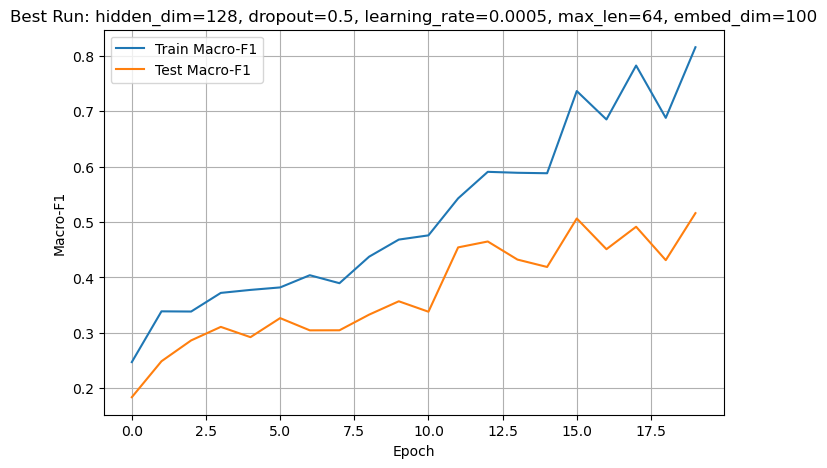

In [ ]:
best_run = max(results, key=lambda x: x["test_macro_f1"])

plt.figure(figsize=(8,5))
plt.plot(best_run["train_f1_history"], label="Train Macro-F1")
plt.plot(best_run["test_f1_history"], label="Test Macro-F1")

plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.title(
    f"Best Run: hidden_dim={best_run['hidden_dim']}, "
    f"dropout={best_run['dropout']}, "
    f"learning_rate={best_run['learning_rate']}, "
    f"max_len={best_run['max_len']}, "
    f"embed_dim={best_run['embed_dim']}"
)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Best model by test macro F1
best_row = df_results.loc[df_results["test_macro_f1"].idxmax()]
print(best_row)


model                                                            LSTM
hidden_dim                                                        128
dropout                                                           0.5
learning_rate                                                  0.0005
max_len                                                            64
embed_dim                                                         100
best_epoch                                                         20
train_macro_f1                                               0.815337
train_acc                                                    0.817811
train_cm                 [[336, 98, 28], [35, 384, 77], [0, 30, 483]]
test_macro_f1                                                0.515975
test_acc                                                     0.518617
test_cm                    [[76, 36, 35], [24, 53, 37], [20, 29, 66]]
train_f1_history    [0.24716483634586495, 0.33874553297160226, 0.3...
test_f1_history     

In [ ]:
# Rank models by test macro F1
df_results.sort_values("test_macro_f1", ascending=False).head(5)


,model,hidden_dim,dropout,learning_rate,max_len,embed_dim,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
69,LSTM,128,0.5,0.0005,64,100,20,0.815337,0.817811,"[[336, 98, 28], [35, 384, 77], [0, 30, 483]]",0.515975,0.518617,"[[76, 36, 35], [24, 53, 37], [20, 29, 66]]","[0.24716483634586495, 0.33874553297160226, 0.3...","[0.18378705082027205, 0.24870178358081585, 0.2..."
33,LSTM,128,0.5,0.0005,32,100,16,0.877374,0.875595,"[[415, 8, 39], [8, 368, 120], [2, 6, 505]]",0.500988,0.518617,"[[101, 25, 21], [44, 49, 21], [37, 33, 45]]","[0.30029532030895045, 0.358044243338361, 0.398...","[0.2591532498509243, 0.2965363244534455, 0.330..."
50,LSTM,128,0.5,0.0010,64,50,27,0.856699,0.858600,"[[348, 86, 28], [6, 411, 79], [0, 9, 504]]",0.500475,0.507979,"[[80, 46, 21], [25, 69, 20], [21, 52, 42]]","[0.30451784267786425, 0.3290584294558257, 0.34...","[0.26077097505668934, 0.30622194427072474, 0.2..."
60,LSTM,64,0.3,0.0010,64,100,13,0.756819,0.760707,"[[306, 116, 40], [31, 333, 132], [2, 31, 480]]",0.495944,0.497340,"[[68, 50, 29], [18, 48, 48], [13, 31, 71]]","[0.18314042335197225, 0.3450180746261711, 0.34...","[0.19159544159544162, 0.2883328730553254, 0.28..."
24,LSTM,64,0.3,0.0010,32,100,12,0.876995,0.878314,"[[434, 7, 21], [28, 350, 118], [2, 3, 508]]",0.493297,0.492021,"[[62, 57, 28], [26, 56, 32], [17, 31, 67]]","[0.37844203507645163, 0.4343878479910255, 0.46...","[0.2860161917002763, 0.33228568971606004, 0.36..."


In [ ]:
# Compare hidden_dim effects
df_results.groupby("hidden_dim")["test_macro_f1"].describe()

,count,mean,std,min,25%,50%,75%,max
hidden_dim,,,,,,,,
32,36.0,0.337703,0.098865,0.165707,0.215653,0.361259,0.424146,0.462339
64,36.0,0.359700,0.107451,0.203451,0.229801,0.388211,0.454925,0.495944
128,36.0,0.369527,0.118761,0.193770,0.222398,0.421996,0.470582,0.515975


In [ ]:
# Compare dropout effects
df_results.groupby("dropout")["test_macro_f1"].describe()


,count,mean,std,min,25%,50%,75%,max
dropout,,,,,,,,
0.3,36.0,0.366572,0.109239,0.165707,0.239672,0.401099,0.463070,0.495944
0.5,36.0,0.360443,0.114168,0.184520,0.229048,0.395094,0.451253,0.515975
0.6,36.0,0.339915,0.102965,0.185149,0.211987,0.382061,0.427512,0.465852


In [ ]:
# Compare learning_rate effects
df_results.groupby("learning_rate")["test_macro_f1"].describe()

,count,mean,std,min,25%,50%,75%,max
learning_rate,,,,,,,,
0.0005,54.0,0.351954,0.112076,0.165707,0.219842,0.390729,0.441758,0.515975
0.0010,54.0,0.359333,0.105666,0.185895,0.233431,0.393511,0.448107,0.500475


In [ ]:
# Compare max_len effects
df_results.groupby("max_len")["test_macro_f1"].describe()

,count,mean,std,min,25%,50%,75%,max
max_len,,,,,,,,
32,36.0,0.445586,0.033789,0.365107,0.431235,0.450181,0.465656,0.500988
64,36.0,0.405908,0.053445,0.317087,0.358674,0.404450,0.431423,0.515975
128,36.0,0.215436,0.028865,0.165707,0.199178,0.210941,0.223723,0.322831


In [ ]:
# Compare embed_dim effects
df_results.groupby("embed_dim")["test_macro_f1"].describe()

,count,mean,std,min,25%,50%,75%,max
embed_dim,,,,,,,,
50,54.0,0.352783,0.106789,0.165707,0.223931,0.387688,0.441758,0.500475
100,54.0,0.358504,0.111056,0.184520,0.221799,0.394513,0.450951,0.515975


In [ ]:
# Best epoch per configuration
df_results.loc[
    df_results.groupby(
        ["hidden_dim", "dropout", "learning_rate", "max_len", "embed_dim"]
    )["test_macro_f1"].idxmax()
]


,model,hidden_dim,dropout,learning_rate,max_len,embed_dim,best_epoch,train_macro_f1,train_acc,train_cm,test_macro_f1,test_acc,test_cm,train_f1_history,test_f1_history
1,LSTM,32,0.3,0.0005,32,50,11,0.621278,0.628824,"[[305, 88, 69], [147, 227, 122], [65, 55, 393]]",0.455658,0.462766,"[[64, 34, 49], [31, 39, 44], [24, 20, 71]]","[0.16911868836183927, 0.18532091854752927, 0.2...","[0.15510204081632653, 0.1793716793716794, 0.23..."
19,LSTM,32,0.3,0.0005,32,100,14,0.612759,0.649898,"[[435, 2, 25], [170, 128, 198], [92, 28, 393]]",0.397774,0.457447,"[[89, 18, 40], [49, 8, 57], [31, 9, 75]]","[0.1749973760584248, 0.3414584176608721, 0.339...","[0.20100586059270956, 0.31080550780503896, 0.2..."
37,LSTM,32,0.3,0.0005,64,50,13,0.521804,0.576479,"[[318, 13, 131], [67, 59, 370], [25, 17, 471]]",0.423808,0.484043,"[[93, 9, 45], [44, 11, 59], [33, 4, 78]]","[0.20227775690259367, 0.2757963003725716, 0.30...","[0.17508646441020623, 0.24611314611314614, 0.2..."
55,LSTM,32,0.3,0.0005,64,100,16,0.538244,0.582597,"[[296, 8, 158], [93, 88, 315], [23, 17, 473]]",0.400336,0.452128,"[[73, 13, 61], [30, 11, 73], [23, 6, 86]]","[0.18318378384755804, 0.24128614236669246, 0.2...","[0.17508646441020623, 0.20338556657072807, 0.2..."
73,LSTM,32,0.3,0.0005,128,50,2,0.192414,0.357580,"[[5, 1, 456], [0, 9, 487], [0, 1, 512]]",0.165707,0.305851,"[[1, 3, 143], [0, 1, 113], [0, 2, 113]]","[0.18129045311403724, 0.19241381268772587]","[0.16096708953851813, 0.16570744298017026]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34,LSTM,128,0.6,0.0010,32,100,8,0.808337,0.808294,"[[371, 65, 26], [58, 374, 64], [5, 64, 444]]",0.438064,0.438830,"[[48, 59, 40], [23, 52, 39], [14, 36, 65]]","[0.3664167873470199, 0.3934866994625803, 0.473...","[0.32706899688566876, 0.32972617561381606, 0.3..."
52,LSTM,128,0.6,0.0010,64,50,10,0.548997,0.581917,"[[255, 68, 139], [83, 122, 291], [10, 24, 479]]",0.427419,0.449468,"[[81, 33, 33], [45, 24, 45], [31, 20, 64]]","[0.3124865491433664, 0.32605714498093, 0.33660...","[0.2826286901053256, 0.28058351306014856, 0.29..."
70,LSTM,128,0.6,0.0010,64,100,16,0.654121,0.687967,"[[380, 18, 64], [49, 127, 320], [7, 1, 505]]",0.383371,0.425532,"[[51, 17, 79], [15, 15, 84], [15, 6, 94]]","[0.318478663101101, 0.34025762406577414, 0.342...","[0.22838734941257566, 0.25708168026548894, 0.3..."
88,LSTM,128,0.6,0.0010,128,50,7,0.261746,0.388171,"[[35, 3, 424], [3, 31, 462], [8, 0, 505]]",0.203378,0.319149,"[[9, 4, 134], [2, 2, 110], [3, 3, 109]]","[0.1942950905432462, 0.21556165841880126, 0.22...","[0.16487908219763195, 0.16862745098039214, 0.1..."


# Clear memory

In [ ]:
del model
torch.cuda.empty_cache()


NameError: name 'model' is not defined